# inspect runs where control outperforms sim/inf 

# setup

In [1]:
import os

import itertools
from itertools import combinations

import pandas as pd 
import csv 
import numpy as np 

import matplotlib.pyplot as plt 
%matplotlib inline 

import seaborn as sns 

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
from Bio import Phylo
import json 

import glob
import re
import tskit 
#from Bio import Phylo 
from io import StringIO

In [4]:
from Bio import AlignIO

In [5]:
location_colors = {"1": "red", 
                   "2": "green", 
                   "3": "blue"}

In [7]:
def get_location_from_traits(traits_file): 
    
    with open(traits_file, 'r') as file: 
        data = json.load(file) 
   
    dict = data['nodes']
    subdict = {key: value for (key, value) in dict.items() if 'N' in key}
    subdict = pd.DataFrame(subdict).transpose()
    
    pops = pd.json_normalize(subdict['population_confidence']).set_index(subdict.index)
    res = subdict.join(pops).drop(columns=['population_confidence'])
    res[['1', '2', '3']] = res[['1', '2', '3']].fillna(0)
    res['node'] = res.index
    return res

In [8]:
network_colors = {"pop_0": "red", "pop_1": "green", "pop_2": "blue"}

In [9]:
def apply_styles(ts): # for 3-deme simulations. update to accept n_demes

    styles = []
    # style for each population
    for colour, p in zip(['red', 'green', 'blue'], ts.populations()): 
        # target the symbols only (class "sym")
        s = f".node.p{p.id} > .sym " + "{" + f"fill: {colour}" + "}"
        styles.append(s)
        #print(f'"{s}" applies to nodes from population {p.metadata["name"]} (id {p.id})')
    css_string = " ".join(styles)
    #print(f'CSS string applied:\n    "{css_string}"')

    colors = {"pop_0": "red", "pop_1": "green", "pop_2": "blue"}
    colors_for_node = {}
    for n in ts.samples():
        population_data = ts.population(ts.node(n).population)
        colors_for_node[n] = colors[population_data.metadata["name"]]
    
    individual_for_node = {}
    for n in ts.samples():
        individual_data = ts.individual(ts.node(n).individual)
        individual_for_node[n] = individual_data.id

    tip_lab = {u: f"{u}:p{ts.node(u).population}" for u in ts.samples()}


    return individual_for_node, css_string, tip_lab, colors_for_node


In [10]:
def apply_styles2(ts): 

    colors = ["red", "green", "blue"]
    N = 3
    
    # map population to color [red = source] 
    mig_color_dict = {}
    for i in range(N):
        rgb = plt.matplotlib.colors.to_rgb(colors[i % len(colors)])
        mig_color_dict[i] = np.array(rgb) * 255
    
    pop = ts.tables.nodes.population
    
    # must explicitly choose tree !!!!!!
    tree = ts.first()
    
    # color coalescent events, migrations, and tips 
    coal_nodes = {u for u in tree.nodes() if tree.num_children(u) >= 2}
    
    tip_nodes = {u for u in tree.nodes() if tree.num_children(u) == 0}
    
    mig_nodes = {m.node for m in ts.migrations()}
    
    show_nodes = coal_nodes | mig_nodes | tip_nodes
    
    # css
    string = ""
    string += ".tree .edge {stroke-width: 3px;}\n"
    
    # hide other stuff e.g. unary nodes
    string += ".node > .sym {opacity: 0;}\n"
    
    # edge colors
    for u in tree.nodes():
        # edge color based on population
        rgb_u = tuple(mig_color_dict[pop[u]][0:3])
        string += f".node.n{u} > .edge {{stroke: rgb{rgb_u};}}\n"
    
    for u in show_nodes:
        rgb_u = tuple(mig_color_dict[pop[u]][0:3])
        string += f".node.n{u} > .sym {{opacity: 1; fill: rgb{rgb_u};}}\n"
    
    for m in ts.migrations():
        rgb_dest = tuple(mig_color_dict[m.dest][0:3])
        string += f".node.n{m.node} > .sym {{opacity: 0.75; fill: rgb{rgb_dest};}}\n"
    
    node_labels = {node.id: "" for node in ts.nodes()}


    return string, node_labels

#### import scores

In [11]:
dir = "../scores/" 
scores = sorted(os.listdir(dir))[1:]

In [12]:
scores[0:5]

['control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-4_seed37.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-4_seed63.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-4_seed89.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-5_seed61.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr5.000e-3_seed39.csv']

In [13]:
list = [score.split("_") for score in scores]
type = [item[0] for item in list]
pm = [item[3][2:] for item in list]
mr = [item[4][2:] for item in list]
seed = [item[5][4:-4] for item in list]

In [14]:
runs = pd.DataFrame(scores, columns= ["path"])
runs['type'] = type
runs['pm'] = pm 
runs['mr'] = mr 
runs['seed'] = seed 
runs['path'] = "scores/" + runs['path']
## find unique combinations of pm/mr (i.e. identify reps) 
runs['rep'] = runs.groupby(['type', 'pm', 'mr']).cumcount() + 1

In [15]:
runs

,path,type,pm,mr,seed,rep
0,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-4,37,1
1,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-4,63,2
2,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-4,89,3
3,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-5,61,1
4,scores/control_ss_mu2.500e-8_pm1.000e-1_mr5.00...,control,1.000e-1,5.000e-3,39,1
...,...,...,...,...,...,...
205,scores/sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-3...,sim,5.000e-3,5.000e-3,76,3
206,scores/sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-4...,sim,5.000e-3,5.000e-4,49,1
207,scores/sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-4...,sim,5.000e-3,5.000e-4,75,2
208,scores/sim_ss_mu2.500e-8_pm5.000e-3_mr5.000e-5...,sim,5.000e-3,5.000e-5,47,1


# pm = 0.05, mr = 1e-4¶

In [78]:
runs[(runs['pm'] == '5.000e-2') & (runs['mr'] == '1.000e-4')]

,path,type,pm,mr,seed,rep
46,scores/control_ss_mu2.500e-8_pm5.000e-2_mr1.00...,control,5.000e-2,1.000e-4,32,1
47,scores/control_ss_mu2.500e-8_pm5.000e-2_mr1.00...,control,5.000e-2,1.000e-4,58,2
48,scores/control_ss_mu2.500e-8_pm5.000e-2_mr1.00...,control,5.000e-2,1.000e-4,84,3
116,scores/inf_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4...,inf,5.000e-2,1.000e-4,32,1
117,scores/inf_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4...,inf,5.000e-2,1.000e-4,58,2
118,scores/inf_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4...,inf,5.000e-2,1.000e-4,84,3
186,scores/sim_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4...,sim,5.000e-2,1.000e-4,32,1
187,scores/sim_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4...,sim,5.000e-2,1.000e-4,58,2
188,scores/sim_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4...,sim,5.000e-2,1.000e-4,84,3


In [79]:
run = runs[(runs['pm'] == '5.000e-2') & (runs['mr'] == '1.000e-4')].iloc[[0,3,6]]

In [80]:
run['pm']

46     5.000e-2
116    5.000e-2
186    5.000e-2
Name: pm, dtype: object

In [81]:
run.iloc[0].path

'scores/control_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4_seed32.csv'

In [82]:
path = "_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4_seed32"

In [83]:
# merge data from each 
data = [] 
for (pm_val, mr_val), group in run.groupby(['pm', 'mr']):
    for _, row in group.iterrows():
        csv_df = pd.read_csv("../" + row['path'])
        csv_df['pm'] = pm_val
        csv_df['mr'] = mr_val
        csv_df['seed'] = row['seed']
        csv_df['type'] = row['type']
        data.append(csv_df)

combined_df = pd.concat(data, ignore_index=True)

combined_df['pm'] = pd.to_numeric(combined_df['pm'])
combined_df['mr'] = pd.to_numeric(combined_df['mr'])

In [84]:
# downsample
bins = 15

combined_df['node_height_log'] = np.log(combined_df['node_height_sim'])
# combined_df['nh_bin'] = combined_df.groupby(['seed', 'pm', 'mr', 'bin', 'position', 'type'])['node_height_log'].transform(
#     lambda x: pd.cut(x, bins=bins, labels=False))
combined_df['nh_bin'] = pd.cut(combined_df['node_height_log'], bins=bins, labels=False)






In [85]:
#downsampled_df = combined_df.copy()

downsample_cols = ['seed', 'pm', 'mr', 'bin', 'position', 'type', 'nh_bin']
downsampled_df = (
    combined_df.groupby(downsample_cols, group_keys=False, dropna=False)
    .apply(lambda x: x.sample(n=min(len(x), 3)))
    .reset_index(drop=True)
)

# binomial glm 
results_dict = {}

for (type_val, pm_val, mr_val), type_df in downsampled_df.groupby(['type', 'pm', 'mr']):
    if len(type_df['score'].unique()) < 2:
        continue
        
    model = smf.glm(formula="score ~ node_height_sim", data=type_df, family=sm.families.Binomial())
    fitted_model = model.fit()
    
    max_sim = type_df['node_height_sim'].max()
    min_sim = max(type_df['node_height_sim'].min(), 1e-4)
    
    dense_grid = pd.DataFrame({
        'node_height_sim': np.logspace(np.log10(min_sim), np.log10(max_sim), 5000)
    })
    dense_grid['predicted_score'] = fitted_model.predict(dense_grid)
    
    # store vals in dic
    results_dict[(type_val, pm_val, mr_val)] = {
        'model': fitted_model,
        'predictions': dense_grid
    }

## plot score curve 

In [86]:
# plot
color_palette = {
    "sim": "#F2AD00",
    "inf": "#00A08A",
    "control": "grey"
}

# color_palette = {
#     "sim": "#F2AD00",
#     "inf": "#00A08A",
#     "ctrl": "grey"
# }

# grid 
pm_vals = sorted(downsampled_df['pm'].unique()) # 4 rows
mr_vals = sorted(downsampled_df['mr'].unique())  # 6 columns

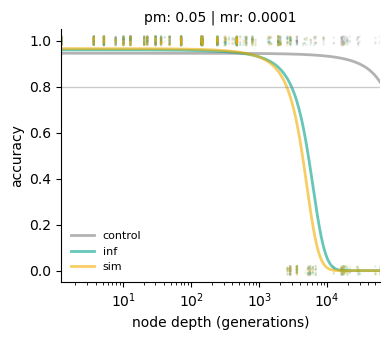

In [87]:
pm_val = pm_vals[0]  
mr_val = mr_vals[0]  

fig, ax = plt.subplots(figsize=(4, 3.5))

run_df = downsampled_df[(downsampled_df['pm'] == pm_val) & (downsampled_df['mr'] == mr_val)]
        
for type_val, type_df in run_df.groupby('type'):
    color = color_palette.get(type_val, "black")

    jittered_y = type_df['score'] + np.random.uniform(-0.02, 0.02, size=len(type_df))
    ax.scatter(
        type_df['node_height_sim'], 
        jittered_y, 
        color=color, 
        alpha=0.15, 
        s=3, 
        edgecolors='none'
    )
    
    dict_key = (type_val, pm_val, mr_val)
    if dict_key in results_dict:
        preds = results_dict[dict_key]['predictions']
        ax.plot(
            preds['node_height_sim'], 
            preds['predicted_score'], 
            color=color, 
            linewidth=2.0, 
            alpha=0.6,
            label=type_val 
        )

ax.axhline(y=0.80, color="grey", linestyle="-", alpha=0.4, linewidth=1)
ax.set_xscale('log')
ax.set_xlim(downsampled_df['node_height_sim'].min(), downsampled_df['node_height_sim'].max())
ax.set_ylim(-0.05, 1.05)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.patch.set_facecolor('white')

ax.set_title(f"pm: {pm_val} | mr: {mr_val}", fontsize=10)
ax.set_xlabel('node depth (generations)', fontsize=10)
ax.set_ylabel('accuracy', fontsize=10)

ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


In [88]:
# subset = downsampled_df[
#     ((downsampled_df['type'] == 'control') & (downsampled_df['score'] == 1)) |
#     ((downsampled_df['type'] != 'control') & (downsampled_df['score'] == 0)) #& (downsampled_df['node_height_sim'] > 10e3)
# ].sort_values(by='node_height_sim', ascending=False)

In [89]:
subset = downsampled_df[(downsampled_df['score'] == 0) #& (downsampled_df['node_height_sim'] > 10e3)
].sort_values(by='node_height_sim', ascending=False)

In [90]:
# subset_corr = downsampled_df[(downsampled_df['score'] == 1) #& (downsampled_df['node_height_sim'] > 10e3)
# ].sort_values(by='node_height_sim', ascending=False)

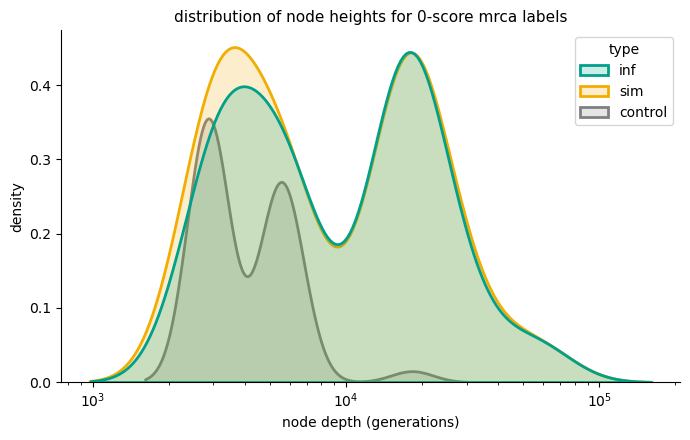

In [92]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot the distribution curves
sns.kdeplot(
    data=subset,
    x='node_height_sim',
    hue='type',
    palette=color_palette,   
    fill=True,
    alpha=0.2,
    linewidth=2,
    log_scale=True,         
    ax=ax
)

# Clean up styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('node depth (generations)', fontsize=10)
ax.set_ylabel('density', fontsize=10)
ax.set_title('distribution of node heights for 0-score mrca labels', fontsize=11)

plt.tight_layout()
plt.show()


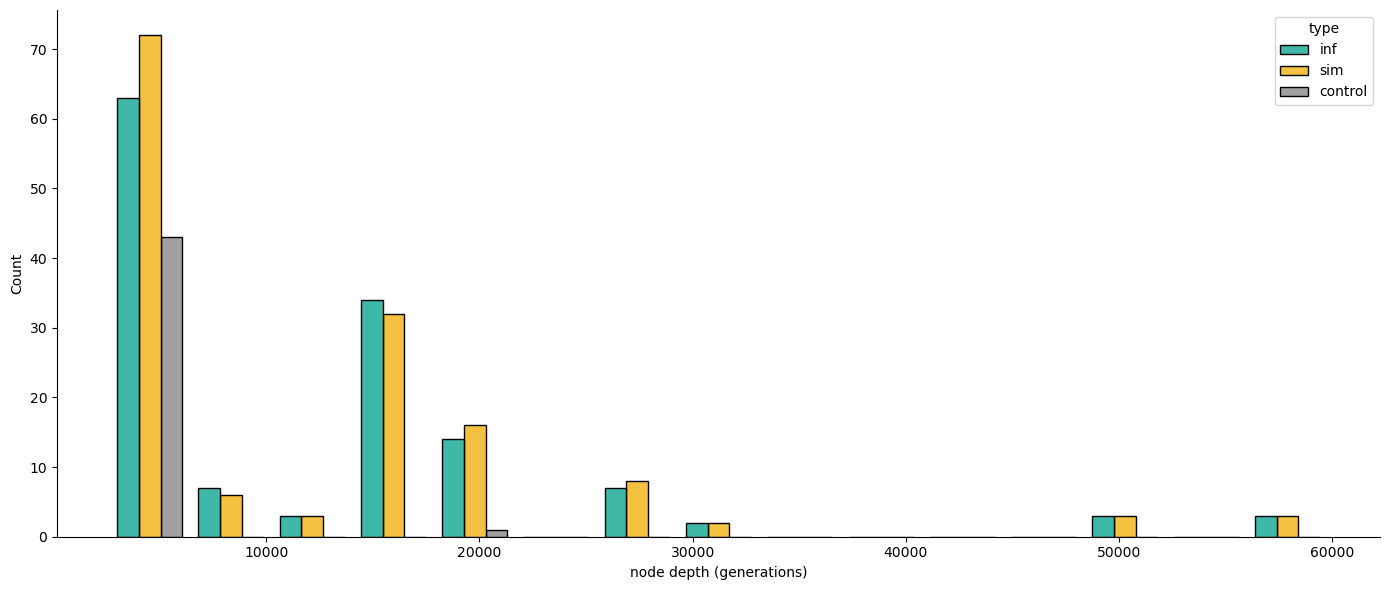

In [93]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.histplot(
    data=subset,
    x='node_height_sim',
    hue='type',
    palette=color_palette,
    multiple='dodge',       
    #log_scale=True,        
    shrink=0.8,             
    ax=ax
)

# 2. Clean up styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('node depth (generations)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()

## what the correct answer was

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


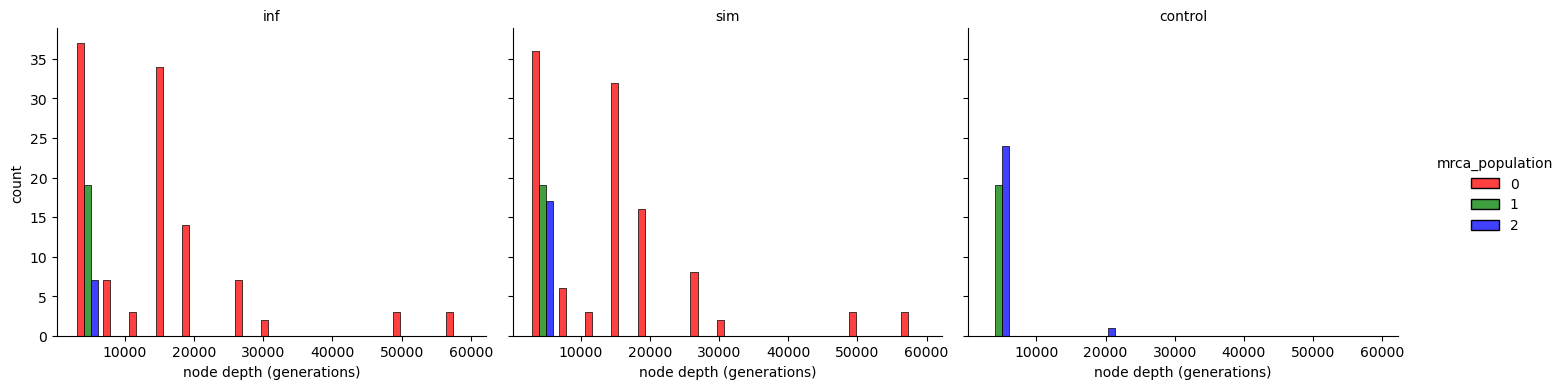

In [94]:

color_palette2 = {
    0: "red",
    1: "green",
    2: "blue"
}

g = sns.displot(
    data=subset,
    x='node_height_sim',
    hue='mrca_population',
    col='type',             
    kind='hist',            
    multiple='dodge',       
    #log_scale=True,        
    shrink=0.8,             
    height=4,              
    aspect=1.2,
    palette=color_palette2,
)

g.set_axis_labels("node depth (generations)", "count")
g.set_titles("{col_name}")


plt.show()

## what the (incorrect) dta guess was 

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


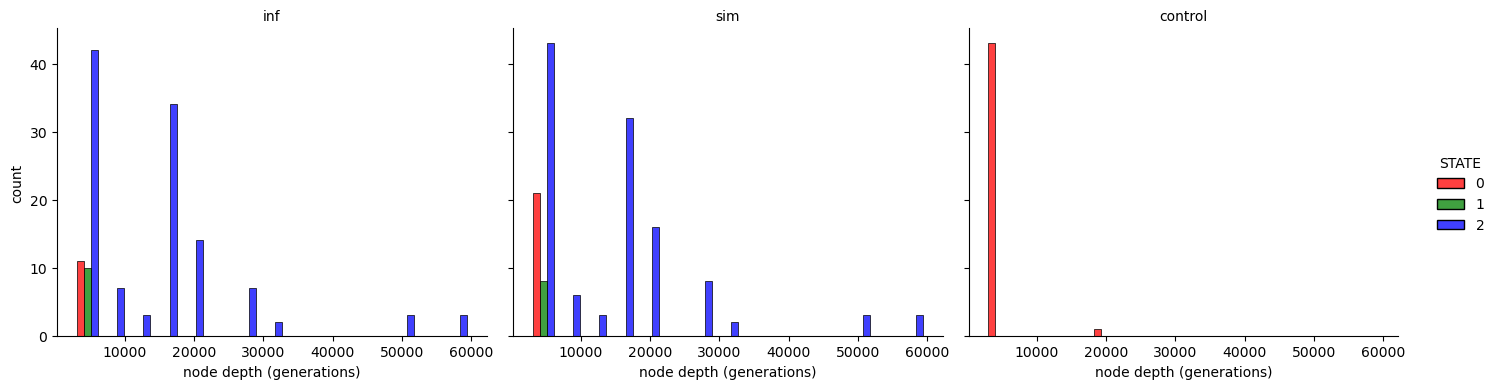

In [95]:
g = sns.displot(
    data=subset,
    x='node_height_sim',
    hue='STATE',
    col='type',             
    kind='hist',            
    multiple='dodge',       
    #log_scale=True,        
    shrink=0.8,            
    height=4,               
    aspect=1.2,
    palette=color_palette2,
)

# Clean up axes and labels across all generated subplots
g.set_axis_labels("node depth (generations)", "count")
g.set_titles("{col_name}")


plt.show()

## incorrect guesses colored by confidence 

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


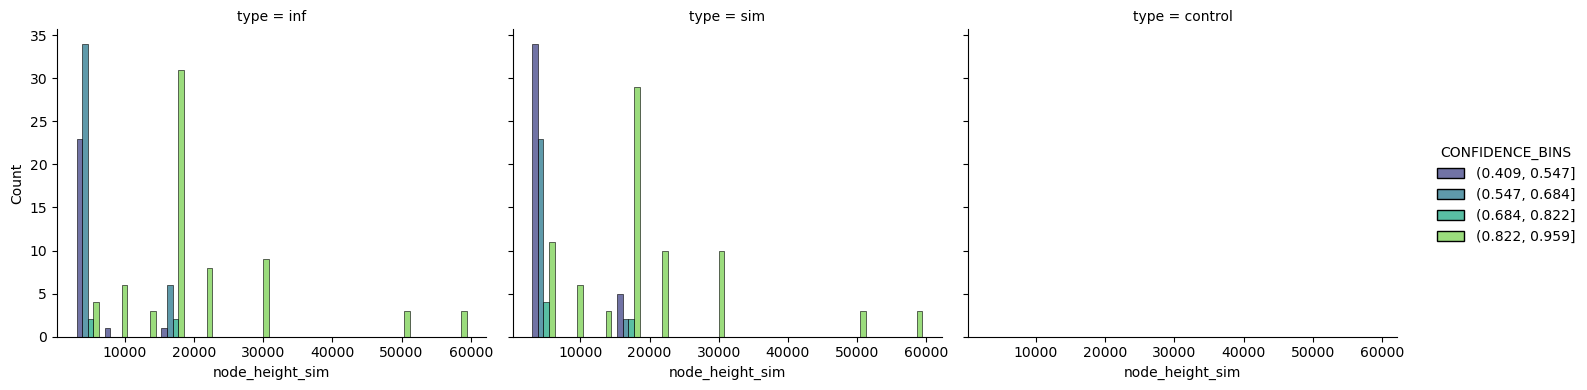

In [96]:
subset['CONFIDENCE_BINS'] = pd.cut(
    subset['CONFIDENCE'], 
    bins=4
)

g = sns.displot(
    data=subset,
    x='node_height_sim',
    hue='CONFIDENCE_BINS',    
    col='type',             
    kind='hist',            
    multiple='dodge',       
    shrink=0.8,            
    height=4,               
    aspect=1.2,
    palette="viridis"          
)

plt.show()

## inspect trees

In [97]:
sim = tskit.load("../../../control/ctrl/trees/sim_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4_seed32.trees") 
inf = tskit.load("../../../control/ctrl/trees/inf_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4_seed32.trees") 
ctrl = Phylo.read("../../../control/ctrl/results/sim_ss_mu2.500e-8_pm5.000e-2_mr1.000e-4_seed32.nwk", format = 'newick')

### format tree

In [98]:
# import traits, location files, tip metadata 

traits = get_location_from_traits("../../../control/ctrl/results/sim"+path+"_traits.json")

meta = pd.read_csv("../../../control/ctrl/metadata/sim"+path+".tsv", sep='\t') 
meta['strain'] = meta['strain'].astype(str)
meta['population'] = meta['population'].astype(str)

nodedict = dict(zip(traits.node,traits.population))
tipdict = dict(zip(meta.strain,meta.population))
popdict = nodedict | tipdict

aln = AlignIO.read("../../../control/ctrl/sim"+path+".filtered_polymorphic_sites.fasta", format = "fasta")

## phylo 
tree = Phylo.read("../../../control/ctrl/results/sim"+path+".nwk", format = "newick") 

for clade in tree.find_clades():
    clade.population = popdict[clade.name]

for clade in tree.find_clades():
    if clade.branch_length is not None:
        clade.branch_length /= 2.5e-8
        clade.branch_length /= (3000000/len(aln[0]))

parents = {}
for parent in tree.find_clades(order="level"):
    for child in parent.clades:
        parents[child] = parent

migration_count = 0
for clade in tree.find_clades():
    if clade in parents:
        parent = parents[clade]
        if hasattr(parent, 'population') and hasattr(clade, 'population'):
            if parent.population != clade.population:
                migration_count += 1

print(f"num_migrations: {migration_count}")

num_migrations: 2


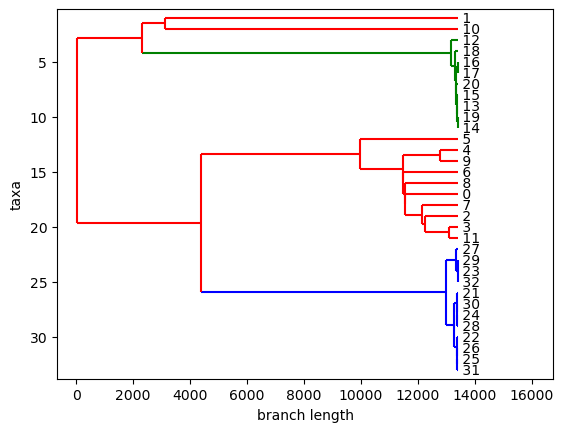

In [99]:
for clade in tree.find_clades():
    loc = getattr(clade, 'population', None)
    
    if loc in location_colors:
        clade.color = location_colors[loc]
    else:
        clade.color = "grey"  # no data 

Phylo.draw(tree, label_func=lambda x: x.name if x.is_terminal() else "", )

In [100]:
max(tree.depths().values())

13401.06590106667

## format network

coloring branches, migration events on branches, and nodes by location

In [101]:
string, node_labels = apply_styles2(sim)

In [102]:
individual_for_node, css_string, tip_lab, colors_for_node = apply_styles(sim)

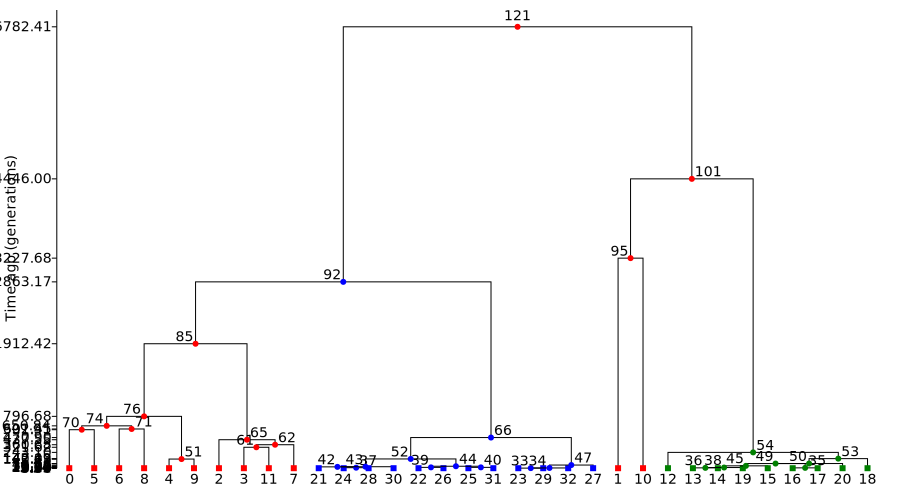

In [103]:
sim.at(1500000).draw_svg(#node_labels={},   
    style=css_string,
    mutation_labels={}, 
    omit_sites = True,
    y_axis = True,
    size = (900,500))

In [ ]:
# sim.draw_svg(node_labels={},   
#     style=css_string,
#     mutation_labels={}, 
#     omit_sites = True,
#     y_axis = True)

# pm = 0.3, mr = 5e-3 

In [105]:
runs[(runs['pm'] == '3.000e-1') & (runs['mr'] == '5.000e-4')]

,path,type,pm,mr,seed,rep
41,scores/control_ss_mu2.500e-8_pm3.000e-1_mr5.00...,control,3.000e-1,5.000e-4,303,1
42,scores/control_ss_mu2.500e-8_pm3.000e-1_mr5.00...,control,3.000e-1,5.000e-4,313,2
111,scores/inf_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4...,inf,3.000e-1,5.000e-4,303,1
112,scores/inf_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4...,inf,3.000e-1,5.000e-4,313,2
181,scores/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4...,sim,3.000e-1,5.000e-4,303,1
182,scores/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4...,sim,3.000e-1,5.000e-4,313,2


In [106]:
run = runs[(runs['pm'] == '3.000e-1') & (runs['mr'] == '5.000e-4')].iloc[[0,2,4]]

In [107]:
run['pm']

41     3.000e-1
111    3.000e-1
181    3.000e-1
Name: pm, dtype: object

In [108]:
run.iloc[0].path

'scores/control_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4_seed303.csv'

In [109]:
path = "_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4_seed303"

In [110]:
# merge data from each 
data = [] 
for (pm_val, mr_val), group in run.groupby(['pm', 'mr']):
    for _, row in group.iterrows():
        csv_df = pd.read_csv("../" + row['path'])
        csv_df['pm'] = pm_val
        csv_df['mr'] = mr_val
        csv_df['seed'] = row['seed']
        csv_df['type'] = row['type']
        data.append(csv_df)

combined_df = pd.concat(data, ignore_index=True)

combined_df['pm'] = pd.to_numeric(combined_df['pm'])
combined_df['mr'] = pd.to_numeric(combined_df['mr'])

In [111]:
# downsample
bins = 15

combined_df['node_height_log'] = np.log(combined_df['node_height_sim'])
# combined_df['nh_bin'] = combined_df.groupby(['seed', 'pm', 'mr', 'bin', 'position', 'type'])['node_height_log'].transform(
#     lambda x: pd.cut(x, bins=bins, labels=False))
combined_df['nh_bin'] = pd.cut(combined_df['node_height_log'], bins=bins, labels=False)






In [112]:
#downsampled_df = combined_df.copy()

downsample_cols = ['seed', 'pm', 'mr', 'bin', 'position', 'type', 'nh_bin']
downsampled_df = (
    combined_df.groupby(downsample_cols, group_keys=False, dropna=False)
    .apply(lambda x: x.sample(n=min(len(x), 3)))
    .reset_index(drop=True)
)

# binomial glm 
results_dict = {}

for (type_val, pm_val, mr_val), type_df in downsampled_df.groupby(['type', 'pm', 'mr']):
    if len(type_df['score'].unique()) < 2:
        continue
        
    model = smf.glm(formula="score ~ node_height_sim", data=type_df, family=sm.families.Binomial())
    fitted_model = model.fit()
    
    max_sim = type_df['node_height_sim'].max()
    min_sim = max(type_df['node_height_sim'].min(), 1e-4)
    
    dense_grid = pd.DataFrame({
        'node_height_sim': np.logspace(np.log10(min_sim), np.log10(max_sim), 5000)
    })
    dense_grid['predicted_score'] = fitted_model.predict(dense_grid)
    
    # store vals in dic
    results_dict[(type_val, pm_val, mr_val)] = {
        'model': fitted_model,
        'predictions': dense_grid
    }

## plot score curve 

In [113]:
# plot
color_palette = {
    "sim": "#F2AD00",
    "inf": "#00A08A",
    "control": "grey"
}

# color_palette = {
#     "sim": "#F2AD00",
#     "inf": "#00A08A",
#     "ctrl": "grey"
# }

# grid 
pm_vals = sorted(downsampled_df['pm'].unique()) # 4 rows
mr_vals = sorted(downsampled_df['mr'].unique())  # 6 columns

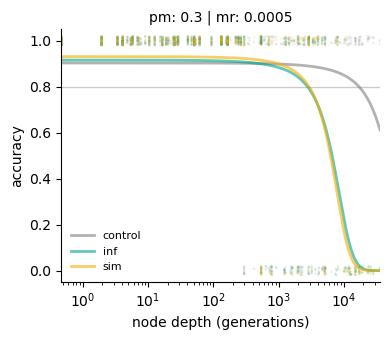

In [114]:
pm_val = pm_vals[0] 
mr_val = mr_vals[0]  

fig, ax = plt.subplots(figsize=(4, 3.5))

run_df = downsampled_df[(downsampled_df['pm'] == pm_val) & (downsampled_df['mr'] == mr_val)]
        
for type_val, type_df in run_df.groupby('type'):
    color = color_palette.get(type_val, "black")

    jittered_y = type_df['score'] + np.random.uniform(-0.02, 0.02, size=len(type_df))
    ax.scatter(
        type_df['node_height_sim'], 
        jittered_y, 
        color=color, 
        alpha=0.15, 
        s=3, 
        edgecolors='none'
    )
    
    dict_key = (type_val, pm_val, mr_val)
    if dict_key in results_dict:
        preds = results_dict[dict_key]['predictions']
        ax.plot(
            preds['node_height_sim'], 
            preds['predicted_score'], 
            color=color, 
            linewidth=2.0, 
            alpha=0.6,
            label=type_val  
        )

ax.axhline(y=0.80, color="grey", linestyle="-", alpha=0.4, linewidth=1)
ax.set_xscale('log')
ax.set_xlim(downsampled_df['node_height_sim'].min(), downsampled_df['node_height_sim'].max())
ax.set_ylim(-0.05, 1.05)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.patch.set_facecolor('white')

ax.set_title(f"pm: {pm_val} | mr: {mr_val}", fontsize=10)
ax.set_xlabel('node depth (generations)', fontsize=10)
ax.set_ylabel('accuracy', fontsize=10)

ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


In [115]:
# subset = downsampled_df[
#     ((downsampled_df['type'] == 'control') & (downsampled_df['score'] == 1)) |
#     ((downsampled_df['type'] != 'control') & (downsampled_df['score'] == 0)) #& (downsampled_df['node_height_sim'] > 10e3)
# ].sort_values(by='node_height_sim', ascending=False)

In [116]:
subset = downsampled_df[(downsampled_df['score'] == 0) #& (downsampled_df['node_height_sim'] > 10e3)
].sort_values(by='node_height_sim', ascending=False)

In [117]:
# subset_corr = downsampled_df[(downsampled_df['score'] == 1) #& (downsampled_df['node_height_sim'] > 10e3)
# ].sort_values(by='node_height_sim', ascending=False)

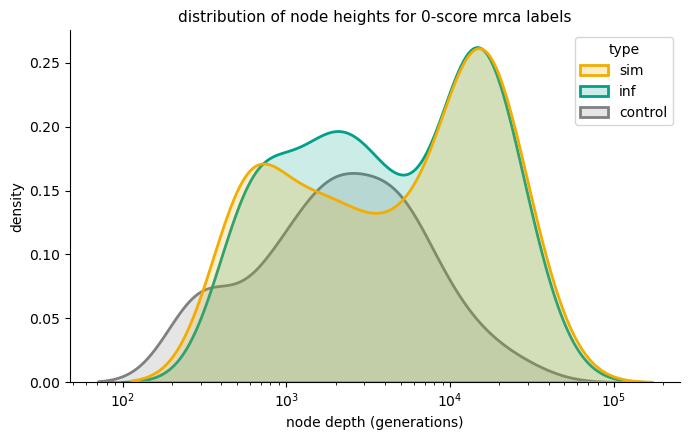

In [119]:
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.kdeplot(
    data=subset,
    x='node_height_sim',
    hue='type',
    palette=color_palette,   
    fill=True,
    alpha=0.2,
    linewidth=2,
    log_scale=True,         
    ax=ax
)

# Clean up styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('node depth (generations)', fontsize=10)
ax.set_ylabel('density', fontsize=10)
ax.set_title('distribution of node heights for 0-score mrca labels', fontsize=11)

plt.tight_layout()
plt.show()


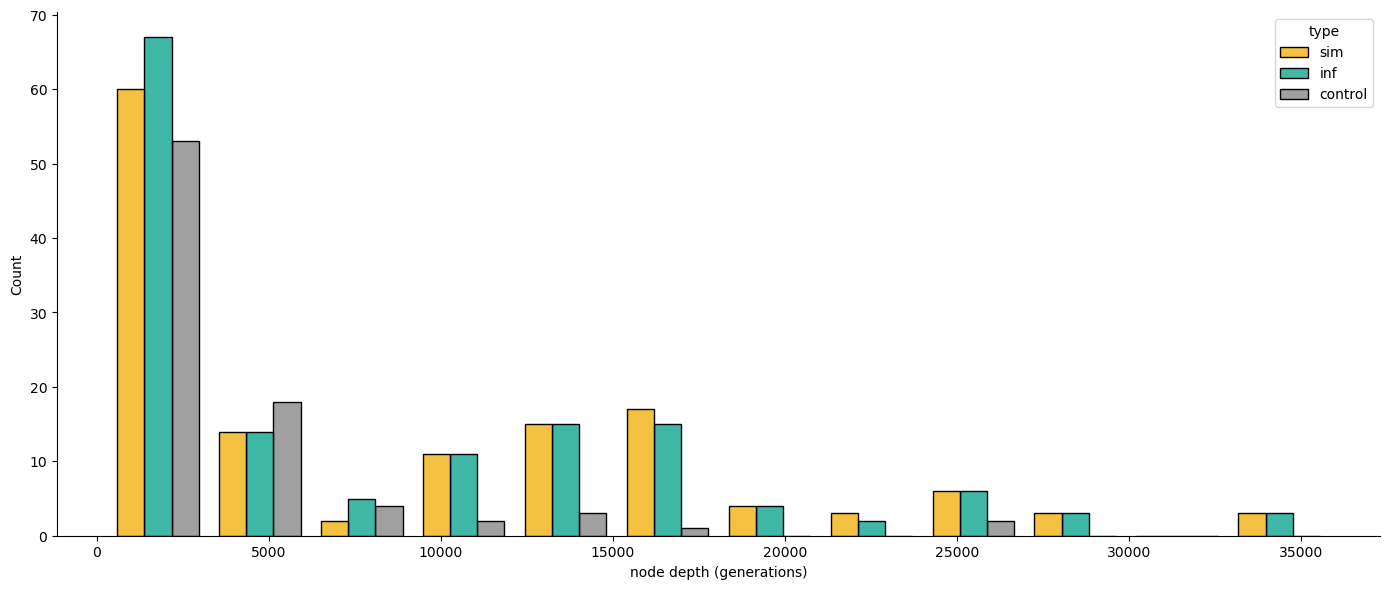

In [120]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.histplot(
    data=subset,
    x='node_height_sim',
    hue='type',
    palette=color_palette,
    multiple='dodge',       
    #log_scale=True,         
    shrink=0.8,             
    ax=ax
)

# 2. Clean up styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('node depth (generations)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

plt.tight_layout()
plt.show()

## what the correct guess was

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


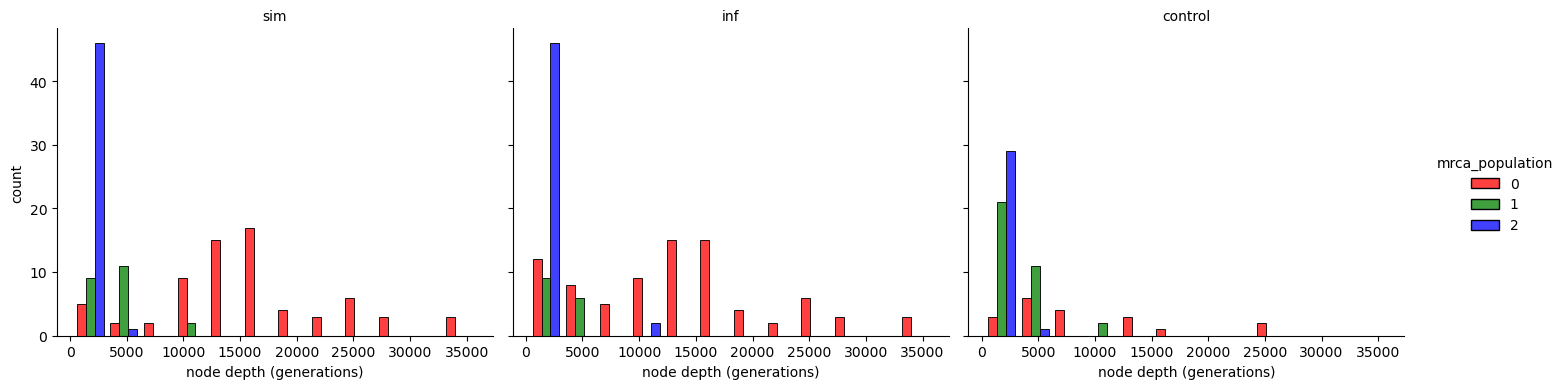

In [121]:

color_palette2 = {
    0: "red",
    1: "green",
    2: "blue"
}

g = sns.displot(
    data=subset,
    x='node_height_sim',
    hue='mrca_population',
    col='type',             
    kind='hist',            
    multiple='dodge',       
    #log_scale=True,        
    shrink=0.8,             
    height=4,              
    aspect=1.2,
    palette=color_palette2,
)

g.set_axis_labels("node depth (generations)", "count")
g.set_titles("{col_name}")


plt.show()

## what the (incorrect) dta guess was 

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


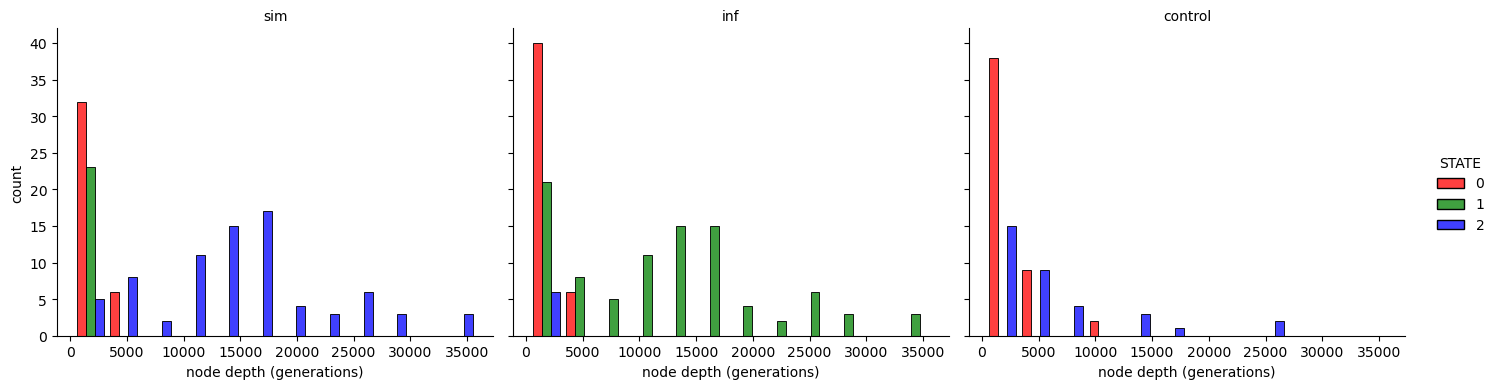

In [122]:
g = sns.displot(
    data=subset,
    x='node_height_sim',
    hue='STATE',
    col='type',             
    kind='hist',            
    multiple='dodge',       
    #log_scale=True,        
    shrink=0.8,            
    height=4,               
    aspect=1.2,
    palette=color_palette2,
)

# Clean up axes and labels across all generated subplots
g.set_axis_labels("node depth (generations)", "count")
g.set_titles("{col_name}")


plt.show()

## incorrect guess colored by confidence 

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


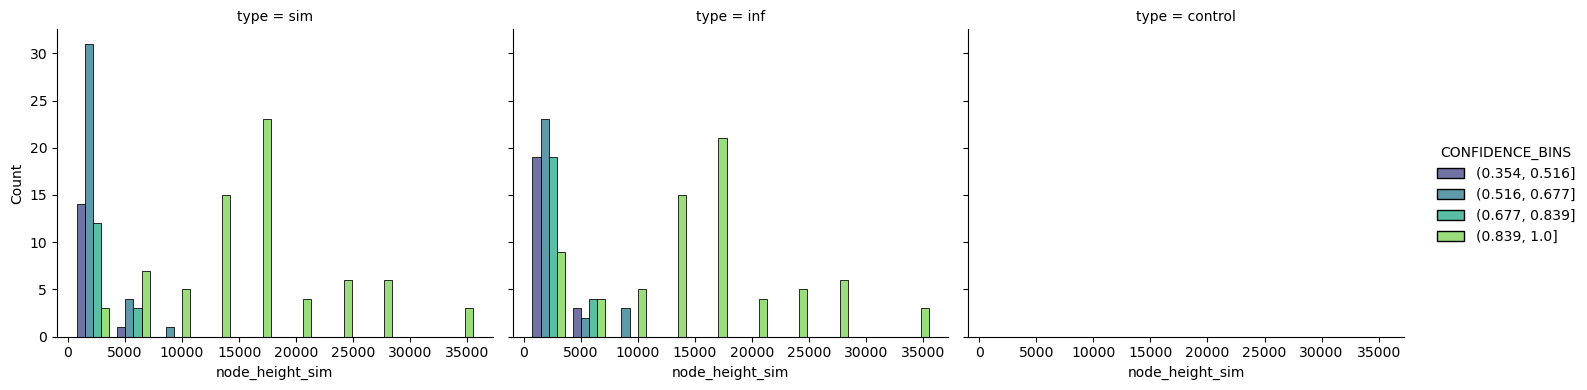

In [123]:
subset['CONFIDENCE_BINS'] = pd.cut(
    subset['CONFIDENCE'], 
    bins=4
)

g = sns.displot(
    data=subset,
    x='node_height_sim',
    hue='CONFIDENCE_BINS',    
    col='type',             
    kind='hist',            
    multiple='dodge',       
    shrink=0.8,            
    height=4,               
    aspect=1.2,
    palette="viridis"          
)

plt.show()

## inspect trees

In [124]:
sim = tskit.load("../../../control/ctrl/trees/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4_seed303.trees") 
inf = tskit.load("../../../control/ctrl/trees/inf_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4_seed303.trees") 
ctrl = Phylo.read("../../../control/ctrl/results/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-4_seed303.nwk", format = 'newick')

### format tree

In [125]:
# import traits, location files, tip metadata 

traits = get_location_from_traits("../../../control/ctrl/results/sim"+path+"_traits.json")

meta = pd.read_csv("../../../control/ctrl/metadata/sim"+path+".tsv", sep='\t') 
meta['strain'] = meta['strain'].astype(str)
meta['population'] = meta['population'].astype(str)

nodedict = dict(zip(traits.node,traits.population))
tipdict = dict(zip(meta.strain,meta.population))
popdict = nodedict | tipdict

aln = AlignIO.read("../../../control/ctrl/sim"+path+".filtered_polymorphic_sites.fasta", format = "fasta")

## phylo 
tree = Phylo.read("../../../control/ctrl/results/sim"+path+".nwk", format = "newick") 

for clade in tree.find_clades():
    clade.population = popdict[clade.name]

for clade in tree.find_clades():
    if clade.branch_length is not None:
        clade.branch_length /= 2.5e-8
        clade.branch_length /= (3000000/len(aln[0]))

parents = {}
for parent in tree.find_clades(order="level"):
    for child in parent.clades:
        parents[child] = parent

migration_count = 0
for clade in tree.find_clades():
    if clade in parents:
        parent = parents[clade]
        if hasattr(parent, 'population') and hasattr(clade, 'population'):
            if parent.population != clade.population:
                migration_count += 1

print(f"num_migrations: {migration_count}")

num_migrations: 2


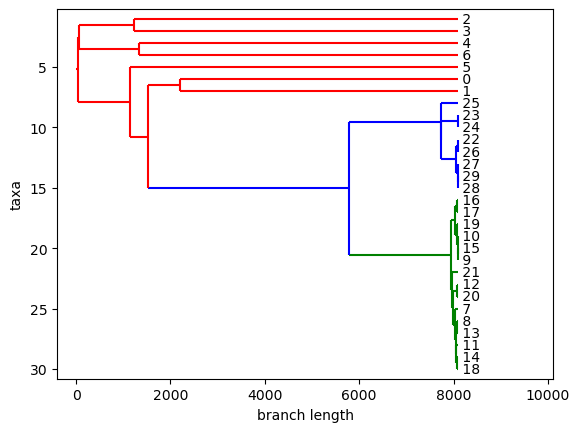

In [126]:
for clade in tree.find_clades():
    loc = getattr(clade, 'population', None)
    
    if loc in location_colors:
        clade.color = location_colors[loc]
    else:
        clade.color = "grey"  # no data 

Phylo.draw(tree, label_func=lambda x: x.name if x.is_terminal() else "", )

In [127]:
max(tree.depths().values())

8085.3730592

## format network

coloring branches, migration events on branches, and nodes by location

In [128]:
string, node_labels = apply_styles2(sim)

In [129]:
individual_for_node, css_string, tip_lab, colors_for_node = apply_styles(sim)

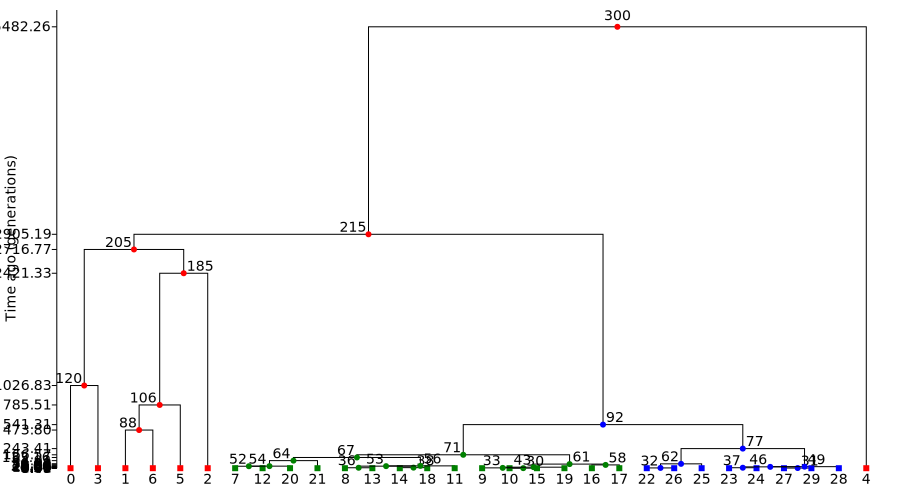

In [130]:
sim.at(1500000).draw_svg(#node_labels={},   
    style=css_string,
    mutation_labels={}, 
    omit_sites = True,
    y_axis = True,
    size = (900,500))

In [ ]:
# sim.draw_svg(node_labels={},   
#     style=css_string,
#     mutation_labels={}, 
#     omit_sites = True,
#     y_axis = True)

# thoughts

- results indicate more mistakes from network+DTA for deeper (older) nodes. these older nodes are often incorrectly labeled as sink locations rather than source.
  - for tree+DTA, we see the opposite; younger nodes are incorrectly labeled as source locations rather than sink.
- network+DTA learns from multiple trees with different migration histories, whereas tree+DTA learns from just one tree.
- maybe: for network+DTA, conflicting routes are learned, leading to less certainty about what the older node locations will be.